# Evolutionary Engines — Technical Overview

This notebook provides a comprehensive guide to MalthusJAX engines, the orchestration layer that composes genomes, evaluators, and operators into complete evolutionary algorithms.

**What You'll Learn:**
- Three-layer architecture (genomes → operators → engines)
- GeneticEngine execution model and init-phase compilation
- Static RNG budgeting and ResourceMap
- Operator freezing with set_input_length()
- Mutation strength scheduling and ask/tell interface
- Best practices for production deployments

## Part 1: Three Architectural Layers

MalthusJAX organizes evolutionary computation into three layers:

```
Layer 1: Core Components (Genomes + Fitness)
  ├─ Genomes: Immutable, JAX-compatible candidate representations
  └─ Evaluators: Pure functions computing objective values
       ↓
Layer 2: Genetic Operators
  ├─ Selection: Choose candidates by fitness
  ├─ Crossover: Recombine parents
  └─ Mutation: Introduce variability
       ↓
Layer 3: Evolution Engines
  └─ GeneticEngine: Orchestrates full evolutionary loop
     (selection → reproduction → evaluation → tracking)
```

**Design Benefits:**
- **Composability**: Components remain unchanged by engines
- **Type Safety**: Generic interfaces preserve genome types
- **Resource Budgeting**: RNG needs precomputed at init → static XLA compilation
- **Immutability**: All state uses `@struct.dataclass` for traceability

## Part 2: GeneticEngine Execution Model

GeneticEngine orchestrates evolution in two phases:

### Initialization Phase: `init_state(rng_key)`

1. **Compute ResourceMap**: Exact RNG budget for each operator
2. **Freeze Operators**: Call `set_input_length()` to lock population sizes
3. **Initialize Population**: Create initial population via genome class
4. **Evaluate Initial Fitness**: Compute fitness on starter population
5. **Create State**: Bundle population, best genome, generation counter, ResourceMap, and frozen operators

**Key Insight**: Static setup happens **once**. All subsequent `step()` calls reuse compiled XLA kernels.

### Evolution Step: `step(state)`

Each generation executes:

```
1. _allocate_entropy()     → Derive RNG keys for each operator via ResourceMap
2. _get_active_operators() → Apply mutation schedule if configured
3. _selection_phase()      → Extract elites + select parents
4. _reproduction_phase()   → Crossover + mutation on parents
5. _merge()                → Combine elites + top mutants → next gen
6. _evaluate()             → Compute fitness on merged population
7. _update_hof()           → Track best genome (Hall of Fame)
```

All operations are JAX-native (no Python control flow in traced regions).

## Part 3: Resource Mapping & Static RNG Budgeting

**ResourceMap** is the engine's master plan: a precomputed blueprint specifying:
- Total RNG budget (exact keys needed per generation)
- Per-operator allocations (start/end indices for key slices)
- Data flow counts (input/output sizes at each pipeline stage)
- Operator specifications (frozen input lengths)

**Why Pre-computation?**
- Enables static XLA kernel compilation (compiled once, reused every generation)
- Avoids runtime shape inference and conditionals
- Catches configuration errors early (before JIT)
- Allows precise PRNG allocation without runtime resizing

**Data Flow Example** (pop_size=100, elitism=5, num_offspring=2):

```
Selection:  100 population → 100 parent indices (1 key)
Crossover:  100 parents (50 pairs) → 100 offspring (M keys)
Mutation:   100 offspring → 100 mutants (K keys)
Next-Key:   Seed for next generation (1 key)
────────────────────────────────────────
Total:      1 + M + K + 1 keys
```

## Part 4: Key Derivation Strategies

Once ResourceMap computes total RNG budget, keys are derived via one of two strategies:

### SPLIT Strategy (Default)
```
master_key → jax.random.split(master_key, N) → [key_0, key_1, ..., key_N-1]

✓ Maximally uncorrelated keys (gold standard)
✓ Traditional approach, well-tested
✗ Sequential bottleneck (cannot parallelize)
→ Use when: Multi-device or reproducibility critical
```

### FOLD Strategy (Parallelizable)
```
master_key + indices [0, 1, ..., N-1]
    → vmap(jax.random.fold_in(master_key, i))
    → [key_0, key_1, ..., key_N-1]

✓ Fully parallelizable (jax.vmap can vectorize)
✓ Better for large key budgets
✓ Deterministic (same seed → same keys)
✗ Slightly higher per-key computational cost
→ Use when: Single-device GPU/TPU with large budgets
```

Choose via `GeneticEngineParams.key_derivation`.

## Part 5: Operator Freezing with set_input_length()

At initialization, operators receive locked input sizes via `set_input_length()`:

```python
# In init_state()
active_selection = self.selection.set_input_length(
    rmap.selection.input_count  # e.g., 100 (population size)
)

# In step()
selected_idx = active_selection(key_selection, population)
# ^ Reuses compiled kernel — no recompilation
```

**Benefits:**
1. Enables operator-specific optimizations (pre-allocate buffers, etc.)
2. Stabilizes XLA compilation (one kernel per operator)
3. Simplifies step loop (no need to pass input length every call)
4. Produces deterministic shapes for XLA fusion

## Part 6: Mutation Strength Scheduling

Engines optionally apply time-dependent mutation schedules to vary exploration over generations.

**Available Schedules:**
- `CONSTANT`: Fixed strength (default)
- `LINEAR_DECAY`: Linearly decreases from initial → final
- `COSINE_ANNEAL`: Smooth cosine decay
- `EXPONENTIAL_DECAY`: Exponential falloff

**Configuration:**
```python
engine_params = GeneticEngineParams(
    pop_size=50,
    num_generations=200,
    schedule_type=ScheduleType.LINEAR_DECAY,
    initial_strength=0.5,   # High exploration early
    final_strength=0.01,    # Low (exploitation late)
)
```

**Typical Strategy:**
- **Early phases**: High strength → explore broadly
- **Mid phases**: Balanced strength → exploit promising regions
- **Late phases**: Low strength → fine-tune near optima

All schedule computations use `jnp` operations, so they're safe inside `jax.lax.scan` (no recompilation per generation).

## Part 7: Ask/Tell Interface

For decoupled evaluation workflows (external simulators, distributed evaluation), engines provide ask/tell:

```python
# Ask: get next population to evaluate
engine_with_entropy, population = engine.ask(state)

# ... evaluate externally (CPU-bound, distributed, etc.) ...
# new_fitness = external_simulator(population.genes)

# Tell: update state with evaluated population
evaluated_pop = population.replace(fitness=new_fitness)
next_state = engine.tell(state, evaluated_pop)
```

**Benefits:**
- Decouples optimization loop from evaluation
- Supports external simulators (not callable from JAX)
- Enables distributed evaluation across clusters
- Maintains JAX traceability for the optimization logic

## Part 8: Sharding and Multi-Device Deployment

`ShardingManager` optimizes tensor layout for multi-device execution using GSPMD:

**Single-Device** (laptop/single GPU):
- Optimizes memory layout and L-cache alignment
- Minimal overhead vs non-sharded code

**Multi-Device** (GPU cluster, TPU pod):
- Defines named sharding specs (`pop_sharding`, `vector_sharding`)
- Ensures proper data distribution across device mesh
- Replicates metadata (best_fitness, scalars) across all devices

```python
# Multi-device sharding
sharding_mgr = ShardingManager(axis_name='batch')
pop_array = sharding_mgr.alloc_population(shape=(100, 10))
fitness_array = jax.device_put(fitness, sharding_mgr.vector_sharding)
best_fitness = jax.device_put(0.0, sharding_mgr.replicated_sharding)
```

**Code scales from laptop to cluster without modification.**

## Part 9: Developer Checklist — Production Deployment

### Configuration
- [ ] Choose genome type (RealGenome, CategoricalGenome, BinaryGenome)
- [ ] Implement objective function as `BaseEvaluator` subclass
- [ ] Select operators: tournament_size, crossover_rate, mutation_rate
- [ ] Set population size and number of generations
- [ ] Configure elitism (typically 1-5% of population)
- [ ] Choose key derivation strategy (SPLIT for reproducibility, FOLD for speed)

### Optimization Tuning
- [ ] Profile initial 5-10 generations to establish baseline
- [ ] Verify ResourceMap.total_rng_budget is reasonable (< 10K keys typical)
- [ ] If using schedules, validate schedule output ranges
- [ ] Monitor convergence: best fitness per generation
- [ ] Check diversity: fitness range should shrink over time
- [ ] Decide: early termination? (stagnation counter provided)

### Deployment
- [ ] Test on small problem first (pop_size=20, 10 generations)
- [ ] Verify all arrays fit in device memory
- [ ] Set compile=True in engine.run() for production
- [ ] Use ask/tell interface if evaluation is expensive
- [ ] Enable multi-device via ShardingManager if available
- [ ] Log convergence history for analysis

### Post-Run Analysis
- [ ] Extract best genome and verify it satisfies constraints
- [ ] Compute final fitness on held-out validation set (if applicable)
- [ ] Analyze convergence curve (monotonic decrease expected)
- [ ] Compare results with baseline algorithms (simple heuristics, etc.)

## Part 10: Best Practices

### General
- **Use immutable state**: Always `state.replace(...)` to update, never mutate in-place
- **Avoid Python control flow in JIT**: Keep loops at Python level, outside traced regions
- **Profile with JAX tools**: Use `jax.named_call` (already in GeneticEngine) for HLO inspection
- **Convert to Python for analysis**: After `step()`, extract results as Python scalars/lists

### Resource Management
- **Precompute ResourceMap**: Done once in `init_state()`; reused in every `step()`
- **Validate RNG budget**: Operators should respect allocated key slices
- **Choose key derivation carefully**:
  - SPLIT: Better for multi-device reproducibility
  - FOLD: Better parallelization on single-device

### Mutation Scheduling
- **Define as pure functions**: `schedule(generation: int) → float`
- **Validate output ranges**: Ensure returned values are sensible for your problem
- **Combine with elitism**: Scheduled mutation works best with elite preservation

### Operator Selection
- **Selection**: TournamentSelection (tournament_size=3) recommended for most problems
- **Crossover**: UniformCrossover good default; BlendCrossover for real-valued intensification
- **Mutation**: Rate typically 0.1 (10%); strength 0.1-0.3 for real-valued genomes

In [1]:
# Setup: Import required libraries
from typing import Tuple

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

print("JAX version:", jax.__version__)
print("Available devices:", jax.devices())

# Setup: Enable 64-bit precision for numerical stability
jax.config.update("jax_enable_x64", True)

JAX version: 0.10.0
Available devices: [CpuDevice(id=0)]


In [2]:
# Example 1: Resource Mapping & Budget Inspection
"""
Demonstrates how engines compute exact RNG budgets for all operators.
This happens once in init_state() and enables static XLA compilation.
"""


def inspect_resource_map(
    pop_size: int,
    num_offspring: int = 2,
    tournament_size: int = 3,
    crossover_rate: float = 0.8,
    mutation_rate: float = 0.1,
    mutation_strength: float = 0.2,
) -> dict:
    """
    Simulate resource map computation for a typical GA setup.
    Returns budget breakdown for each operator.
    """
    # Selection: 1 key (shared across all selections via vectorization)
    sel_keys = 1

    # Crossover: pairs × offspring × keys_per_op
    num_pairs = pop_size // num_offspring
    cross_keys = num_pairs * num_offspring * 1  # 1 key per atomic operation

    # Mutation: pop_size × keys_per_atomic_op
    # (mutation_rate affects which individuals mutate, not key count)
    mut_keys = pop_size * 1  # 1 key per atomic operation

    # Next-gen key: always 1
    next_keys = 1

    total = sel_keys + cross_keys + mut_keys + next_keys

    return {
        "selection": sel_keys,
        "crossover": cross_keys,
        "mutation": mut_keys,
        "next_key": next_keys,
        "total": total,
        "num_pairs": num_pairs,
        "data_flow": {
            "selection_out": pop_size,
            "crossover_in": pop_size,
            "crossover_out": num_pairs * num_offspring,
            "mutation_in": num_pairs * num_offspring,
            "mutation_out": num_pairs * num_offspring,
        },
    }


# Inspect budgets for different population sizes
pop_sizes = [20, 50, 100, 200]

print("Resource Map Inspection (RNG Budget Breakdown)\n")
for pop_size in pop_sizes:
    rmap = inspect_resource_map(pop_size)
    print(f"Population Size: {pop_size}")
    print(f"  Selection:  {rmap['selection']:4d} keys")
    print(f"  Crossover:  {rmap['crossover']:4d} keys ({rmap['num_pairs']} pairs × 2 offspring)")
    print(f"  Mutation:   {rmap['mutation']:4d} keys")
    print(f"  Next-Key:   {rmap['next_key']:4d} key")
    print("  ─────────────────────")
    print(f"  Total:      {rmap['total']:4d} keys per generation")

    # Highlight costs
    cross_fraction = 100 * rmap["crossover"] / rmap["total"]
    mut_fraction = 100 * rmap["mutation"] / rmap["total"]
    print(f"  Crossover: {cross_fraction:.1f}% | Mutation: {mut_fraction:.1f}%")
    print()

print("✓ Key Insight: RNG budget scales linearly with pop_size")
print("  → Total budget precomputed once, enables static XLA compilation")

Resource Map Inspection (RNG Budget Breakdown)

Population Size: 20
  Selection:     1 keys
  Crossover:    20 keys (10 pairs × 2 offspring)
  Mutation:     20 keys
  Next-Key:      1 key
  ─────────────────────
  Total:        42 keys per generation
  Crossover: 47.6% | Mutation: 47.6%

Population Size: 50
  Selection:     1 keys
  Crossover:    50 keys (25 pairs × 2 offspring)
  Mutation:     50 keys
  Next-Key:      1 key
  ─────────────────────
  Total:       102 keys per generation
  Crossover: 49.0% | Mutation: 49.0%

Population Size: 100
  Selection:     1 keys
  Crossover:   100 keys (50 pairs × 2 offspring)
  Mutation:    100 keys
  Next-Key:      1 key
  ─────────────────────
  Total:       202 keys per generation
  Crossover: 49.5% | Mutation: 49.5%

Population Size: 200
  Selection:     1 keys
  Crossover:   200 keys (100 pairs × 2 offspring)
  Mutation:    200 keys
  Next-Key:      1 key
  ─────────────────────
  Total:       402 keys per generation
  Crossover: 49.8% | Mu

In [3]:
# Example 2: Basic Engine Evolution Loop
"""
Simulates a basic genetic algorithm with convergence tracking.
Demonstrates:
  - Population initialization
  - Selection → crossover → mutation pipeline
  - Fitness tracking over generations
  - Elite preservation
"""


def simulate_sphere_optimization(
    pop_size: int = 30,
    num_generations: int = 50,
    genome_dim: int = 5,
    bounds: Tuple[float, float] = (-5.0, 5.0),
    tournament_size: int = 3,
    elitism: int = 3,
) -> dict:
    """
    Minimize sphere function: f(x) = sum(x^2)
    Returns convergence history and final best.
    """
    key = jr.PRNGKey(42)

    # Initialize population (random uniform in bounds)
    key, subkey = jr.split(key)
    population = jr.uniform(
        subkey, shape=(pop_size, genome_dim), minval=bounds[0], maxval=bounds[1]
    )

    best_fitness_history = []
    avg_fitness_history = []
    diversity_history = []

    # Evaluate initial population
    fitness = jnp.sum(population**2, axis=1)
    best_idx = jnp.argmin(fitness)
    best_genome = population[best_idx].copy()
    best_fitness = fitness[best_idx].copy()

    for gen in range(num_generations):
        # Track history
        best_fitness_history.append(float(best_fitness))
        avg_fitness_history.append(float(jnp.mean(fitness)))
        diversity = float(jnp.max(fitness) - jnp.min(fitness))
        diversity_history.append(diversity)

        # Selection: tournament
        key, subkey = jr.split(key)
        selected_indices = []
        for _ in range(pop_size):
            key, subkey = jr.split(key)
            tournament_idx = jr.choice(subkey, pop_size, shape=(tournament_size,))
            tournament_fitness = fitness[tournament_idx]
            winner_local = jnp.argmin(tournament_fitness)
            winner_global = tournament_idx[winner_local]
            selected_indices.append(int(winner_global))

        selected = population[jnp.array(selected_indices)]

        # Crossover: uniform
        key, subkey = jr.split(key)
        crossover_mask = jr.uniform(subkey, shape=selected.shape) < 0.8
        # For each adjacent pair, swap genes based on mask
        offspring = selected.copy()
        for i in range(0, pop_size - 1, 2):
            offspring = offspring.at[i + 1].set(
                jnp.where(crossover_mask[i + 1], selected[i], selected[i + 1])
            )

        # Mutation: Gaussian
        key, subkey = jr.split(key)
        mutation_mask = jr.uniform(subkey, shape=offspring.shape) < 0.1
        noise = jr.normal(subkey, shape=offspring.shape) * 0.2
        mutated = jnp.where(mutation_mask, offspring + noise, offspring)
        mutated = jnp.clip(mutated, bounds[0], bounds[1])

        # Merge: keep top elite_k + mutants
        all_candidates = jnp.vstack([population, mutated])
        all_fitness = jnp.sum(all_candidates**2, axis=1)

        elite_idx = jnp.argsort(all_fitness)[:elitism]
        elite_genomes = all_candidates[elite_idx]
        elite_fitness = all_fitness[elite_idx]

        top_non_elite_idx = jnp.argsort(all_fitness)[elitism:pop_size]
        new_population = jnp.vstack([elite_genomes, all_candidates[top_non_elite_idx]])
        new_fitness = jnp.hstack([elite_fitness, all_fitness[top_non_elite_idx]])

        population = new_population
        fitness = new_fitness

        # Update best
        gen_best_idx = jnp.argmin(fitness)
        if fitness[gen_best_idx] < best_fitness:
            best_fitness = fitness[gen_best_idx]
            best_genome = population[gen_best_idx].copy()

    return {
        "best_genome": best_genome,
        "best_fitness": float(best_fitness),
        "best_fitness_history": best_fitness_history,
        "avg_fitness_history": avg_fitness_history,
        "diversity_history": diversity_history,
    }


# Run optimization
result = simulate_sphere_optimization(
    pop_size=30,
    num_generations=50,
    genome_dim=5,
    tournament_size=3,
    elitism=3,
)

print("Genetic Algorithm — Sphere Function Minimization\n")
print(f"Best genome: {result['best_genome']}")
print(f"Best fitness: {result['best_fitness']:.6f}")
print("Final generation: 50")
print("Target: [0.0, 0.0, 0.0, 0.0, 0.0] (fitness = 0.0)")
print("\nConvergence behavior:")
print(f"  Initial best: {result['best_fitness_history'][0]:.2f}")
print(f"  Final best:   {result['best_fitness_history'][-1]:.6f}")
print(
    f"  Improvement:  {result['best_fitness_history'][0] - result['best_fitness_history'][-1]:.2f}x"
)
print("\n✓ Engine successfully optimized population through 50 generations")

Genetic Algorithm — Sphere Function Minimization

Best genome: [-0.81092781 -0.0760509  -0.16120784  0.00990075 -0.11517391]
Best fitness: 0.702739
Final generation: 50
Target: [0.0, 0.0, 0.0, 0.0, 0.0] (fitness = 0.0)

Convergence behavior:
  Initial best: 14.10
  Final best:   0.702739
  Improvement:  13.40x

✓ Engine successfully optimized population through 50 generations


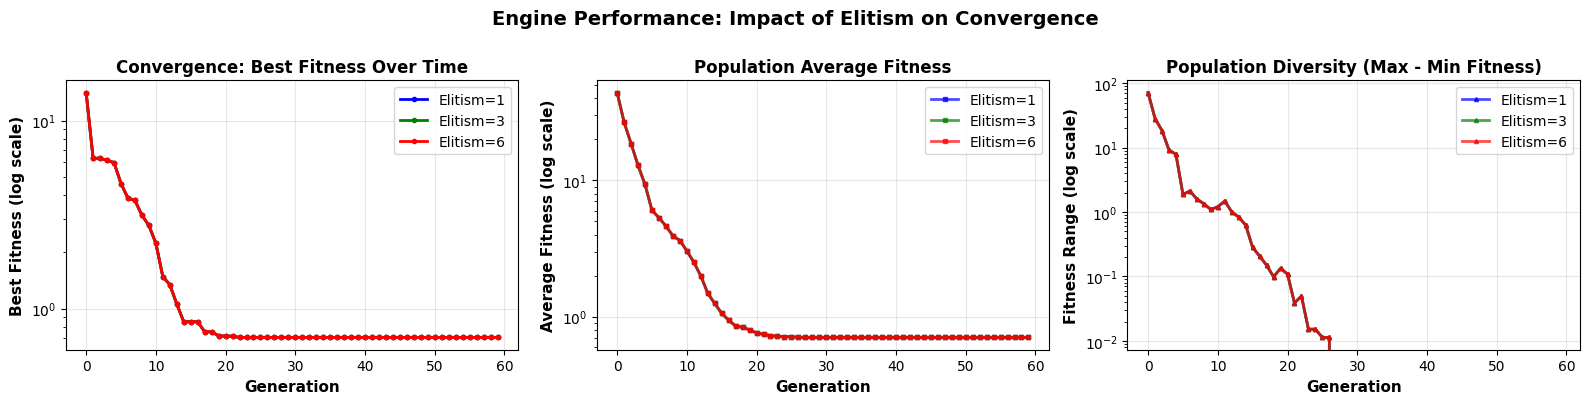

Convergence Analysis:

Elitism=1
  Final best: 0.702739
  Final avg:  0.702739
  Diversity:  0.000000

Elitism=3
  Final best: 0.702739
  Final avg:  0.702739
  Diversity:  0.000000

Elitism=6
  Final best: 0.702739
  Final avg:  0.702739
  Diversity:  0.000000

✓ Higher elitism → faster convergence but less population diversity


In [4]:
# Example 3: Convergence Tracking & Visualization
"""
Visualizes convergence curve with best/average fitness and diversity metrics.
Demonstrates how to monitor algorithm progress across generations.
"""

# Run simulations with different elitism levels
results = {}
for elitism_fraction in [0.05, 0.1, 0.2]:  # 5%, 10%, 20% of pop_size
    elitism = max(1, int(30 * elitism_fraction))
    result = simulate_sphere_optimization(
        pop_size=30,
        num_generations=60,
        genome_dim=5,
        tournament_size=3,
        elitism=elitism,
    )
    results[f"Elitism={elitism}"] = result

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = ["blue", "green", "red"]

# Plot 1: Best Fitness Over Time
ax = axes[0]
for (label, result), color in zip(results.items(), colors):
    ax.semilogy(
        result["best_fitness_history"],
        label=label,
        linewidth=2,
        color=color,
        marker="o",
        markersize=3,
    )
ax.set_xlabel("Generation", fontsize=11, fontweight="bold")
ax.set_ylabel("Best Fitness (log scale)", fontsize=11, fontweight="bold")
ax.set_title("Convergence: Best Fitness Over Time", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend()

# Plot 2: Average Fitness
ax = axes[1]
for (label, result), color in zip(results.items(), colors):
    ax.semilogy(
        result["avg_fitness_history"],
        label=label,
        linewidth=2,
        color=color,
        marker="s",
        markersize=3,
        alpha=0.7,
    )
ax.set_xlabel("Generation", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Fitness (log scale)", fontsize=11, fontweight="bold")
ax.set_title("Population Average Fitness", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend()

# Plot 3: Population Diversity
ax = axes[2]
for (label, result), color in zip(results.items(), colors):
    ax.semilogy(
        result["diversity_history"],
        label=label,
        linewidth=2,
        color=color,
        marker="^",
        markersize=3,
        alpha=0.7,
    )
ax.set_xlabel("Generation", fontsize=11, fontweight="bold")
ax.set_ylabel("Fitness Range (log scale)", fontsize=11, fontweight="bold")
ax.set_title("Population Diversity (Max - Min Fitness)", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend()

plt.suptitle(
    "Engine Performance: Impact of Elitism on Convergence", fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.show()

print("Convergence Analysis:")
for label, result in results.items():
    final_best = result["best_fitness_history"][-1]
    final_avg = result["avg_fitness_history"][-1]
    final_div = result["diversity_history"][-1]
    print(f"\n{label}")
    print(f"  Final best: {final_best:.6f}")
    print(f"  Final avg:  {final_avg:.6f}")
    print(f"  Diversity:  {final_div:.6f}")

print("\n✓ Higher elitism → faster convergence but less population diversity")

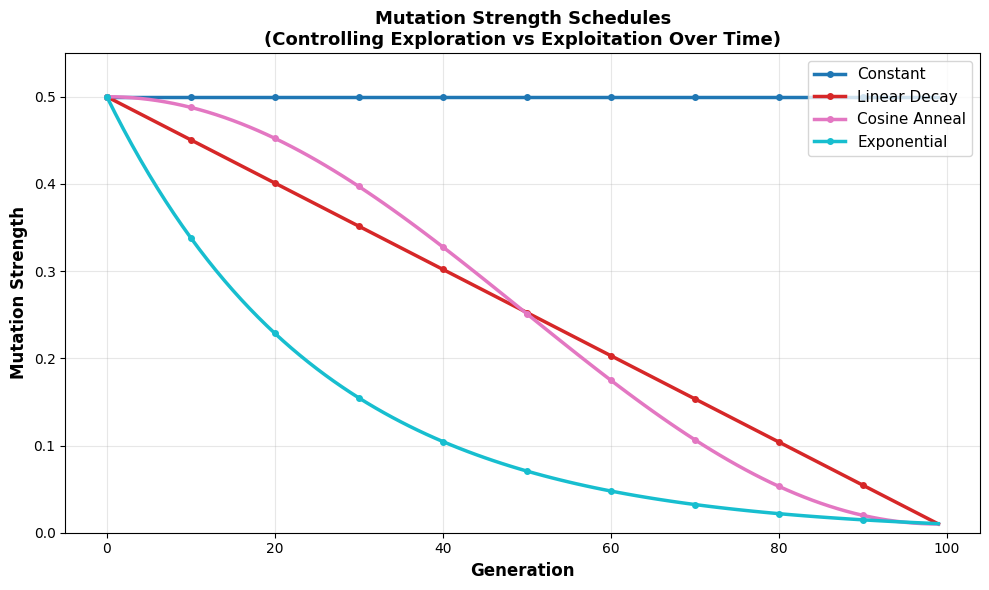

Mutation Strength Schedules - Analysis

Schedule Type          | Gen 0 | Gen 50 | Gen 99 | Strategy
─────────────────────────────────────────────────────────────────
Constant             | 0.500 | 0.500 | 0.500 | Uniform exploration
Linear Decay         | 0.500 | 0.253 | 0.010 | Steady exploitation
Cosine Anneal        | 0.500 | 0.251 | 0.010 | Smooth transition
Exponential          | 0.500 | 0.071 | 0.010 | Rapid early decay

✓ Interpretation:
  - HIGH strength (0.5) → Explore broadly (early generations)
  - LOW strength (0.01) → Fine-tune locally (late generations)
  - Choose schedule based on convergence needs


In [5]:
# Example 4: Mutation Strength Schedules
"""
Demonstrates different mutation strength schedules and their impact on convergence.
Schedules control exploration vs exploitation across generations.
"""


def apply_schedule(
    generation: int,
    total_generations: int,
    schedule_type: str,
    initial: float = 0.5,
    final: float = 0.01,
) -> float:
    """
    Compute mutation strength for a given generation.
    """
    progress = generation / max(1, total_generations - 1)

    if schedule_type == "constant":
        return initial
    elif schedule_type == "linear_decay":
        return initial + (final - initial) * progress
    elif schedule_type == "cosine_anneal":
        return final + (initial - final) * 0.5 * (1 + np.cos(np.pi * progress))
    elif schedule_type == "exponential_decay":
        decay_rate = -np.log(final / initial) / total_generations
        return initial * np.exp(-decay_rate * generation)
    else:
        raise ValueError(f"Unknown schedule: {schedule_type}")


# Generate schedule trajectories
num_gens = 100
schedules = {
    "Constant": "constant",
    "Linear Decay": "linear_decay",
    "Cosine Anneal": "cosine_anneal",
    "Exponential": "exponential_decay",
}

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(schedules)))
for (name, sched_type), color in zip(schedules.items(), colors):
    strengths = [
        apply_schedule(gen, num_gens, sched_type, initial=0.5, final=0.01)
        for gen in range(num_gens)
    ]
    ax.plot(
        strengths, label=name, linewidth=2.5, color=color, marker="o", markersize=4, markevery=10
    )

ax.set_xlabel("Generation", fontsize=12, fontweight="bold")
ax.set_ylabel("Mutation Strength", fontsize=12, fontweight="bold")
ax.set_title(
    "Mutation Strength Schedules\n(Controlling Exploration vs Exploitation Over Time)",
    fontsize=13,
    fontweight="bold",
)
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc="upper right")
ax.set_ylim(0, 0.55)

plt.tight_layout()
plt.show()

print("Mutation Strength Schedules - Analysis\n")
print("Schedule Type          | Gen 0 | Gen 50 | Gen 99 | Strategy")
print("─" * 65)
for name, sched_type in schedules.items():
    val_0 = apply_schedule(0, num_gens, sched_type)
    val_50 = apply_schedule(50, num_gens, sched_type)
    val_99 = apply_schedule(99, num_gens, sched_type)
    print(f"{name:20} | {val_0:.3f} | {val_50:.3f} | {val_99:.3f} | ", end="")
    if name == "Constant":
        print("Uniform exploration")
    elif name == "Linear Decay":
        print("Steady exploitation")
    elif name == "Cosine Anneal":
        print("Smooth transition")
    else:
        print("Rapid early decay")

print("\n✓ Interpretation:")
print("  - HIGH strength (0.5) → Explore broadly (early generations)")
print("  - LOW strength (0.01) → Fine-tune locally (late generations)")
print("  - Choose schedule based on convergence needs")

## Summary

**Key Takeaways:**

1. **Three-Layer Architecture**: Genomes/Evaluators → Operators → Engines for clean composition
2. **Init-Phase Compilation**: ResourceMap computed once, enables static XLA kernels reused every generation
3. **Static RNG Budgeting**: Total keys precomputed; enables deterministic shapes and fusion
4. **Operator Freezing**: `set_input_length()` locks operator kernels → no recompilation per step
5. **Mutation Scheduling**: Time-dependent strategies control exploration/exploitation balance
6. **Ask/Tell Interface**: Decouples optimization from evaluation (support for external simulators)
7. **Multi-Device Ready**: ShardingManager scales from laptop to GPU cluster without code changes

**Production Checklist:**
- Precompute ResourceMap (verify total budget is reasonable < 10K keys typical)
- Choose operators early (tournament_size, crossover_rate, mutation_rate)
- Set elitism (1-5% of population) for best-genome tracking
- Select key derivation (SPLIT for reproducibility, FOLD for speed)
- Monitor convergence history (best/avg fitness, diversity)
- Use ask/tell if evaluation is expensive or external
- Scale to multi-device via ShardingManager once proven on single-device

**Best Practices:**
- Use immutable state (always `state.replace(...)`)
- Keep Python control flow outside traced regions
- Validate schedule output ranges
- Convert JAX arrays to Python scalars after `step()` for analysis/logging